# 01. Data and features

Before any modelling, we need two things: clean prices, and a sensible way to measure
how volatile each day was. This notebook loads 21 years of SPY prices, checks them,
and builds the pieces the forecasts will use. It also fixes one small scaling detail
that matters later for the strategy and the VaR.

In [1]:
import sys
sys.path.append("..")   # so we can import the src package from inside notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_ohlc, validate_prices
from src.features import build_feature_table

ANN = np.sqrt(252)   # scales a daily volatility up to an annual one
pd.set_option("display.width", 200, "display.max_columns", 20)

In [2]:
prices = load_ohlc("../data/raw/spy.csv")
validate_prices(prices)   # a quick health check on the data

{'n_rows': 5337,
 'first_date': '2005-01-03',
 'last_date': '2026-03-20',
 'missing_values': 0,
 'non_positive_prices': 0,
 'high_lt_low_count': 0,
 'duplicated_dates': 0,
 'max_gap_days': 5}

The checks come back clean: 5337 trading days from 2005 to 2026, nothing missing, no
silly prices, and no day where the high is below the low. Good to build on.

In [3]:
feat = build_feature_table(prices)
print("shape:", feat.shape)
feat.head()   # log return, the volatility estimate (rv), the three HAR lags, and tomorrow's rv

shape: (5315, 6)


,log_return,rv,rv_d,rv_w,rv_m,rv_next
Date,,,,,,
2005-02-02,0.003023,0.003942,0.003942,0.004365,0.005422,0.003471
2005-02-03,-0.002602,0.003471,0.003471,0.004166,0.005182,0.005702
2005-02-04,0.010619,0.005702,0.005702,0.004173,0.005028,0.003159
2005-02-07,-0.001332,0.003159,0.003159,0.004197,0.004881,0.003401
2005-02-08,0.001165,0.003401,0.003401,0.003935,0.004798,0.004514


## The scaling detail

Our volatility estimate (Garman-Klass) reads the day's range, from the open to the
close. That range never includes the jump from last night's close to this morning's
open, so the estimate sits a bit below the true close to close volatility that the
strategy actually trades on.

The fix is one number. Take the first 504 days, compare the close to close volatility
with the Garman-Klass average, and use that ratio to scale everything onto the traded
footing. It is fitted only on those early days, well before the test period, so it
never sees the future.

In [4]:
burn = feat.iloc[:504]                                  # first two years only
scale_k = float(burn["log_return"].std() / burn["rv"].mean())
print("scale_k:", round(scale_k, 4))
print("annual realised vol after scaling: %.1f%%" % (feat["rv"].mean() * scale_k * ANN * 100))

scale_k: 1.1692
annual realised vol after scaling: 14.0%


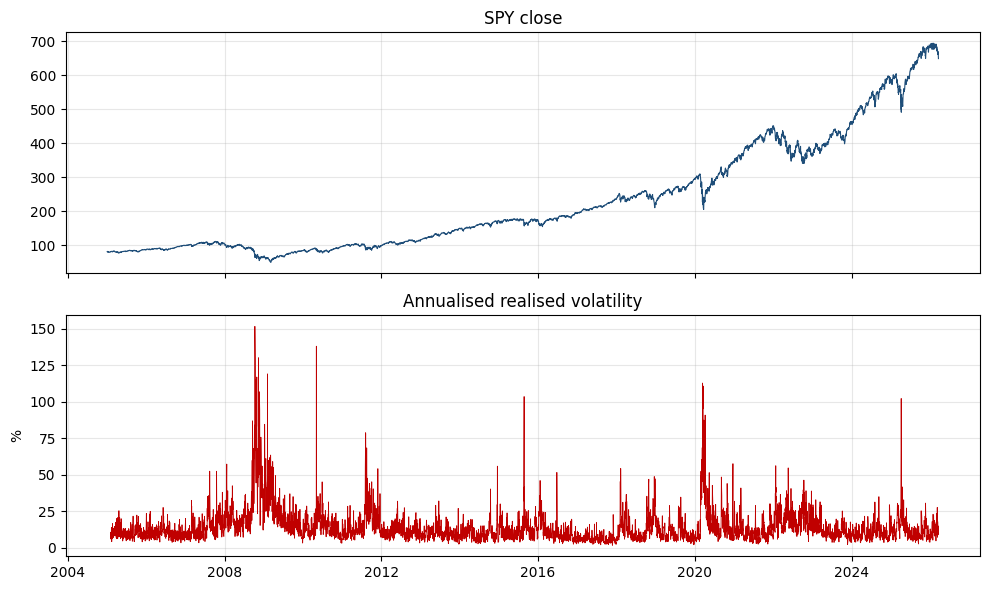

In [5]:
# Price on top, annualised volatility underneath, so you can see the two together.
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(prices.index, prices["Close"], color="#1f4e79", lw=0.8)
ax[0].set_title("SPY close"); ax[0].grid(alpha=0.3)
ax[1].plot(feat.index, feat["rv"] * scale_k * ANN * 100, color="#c00000", lw=0.6)
ax[1].set_title("Annualised realised volatility"); ax[1].set_ylabel("%"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

Every volatility spike lines up with a crisis the strategy will have to survive: 2008,
the 2011 and 2015 selloffs, the 2018 volatility blowup, the COVID crash in 2020, and
the 2022 bear market. Calm most of the time, violent occasionally. That is exactly the
pattern volatility models are built for.

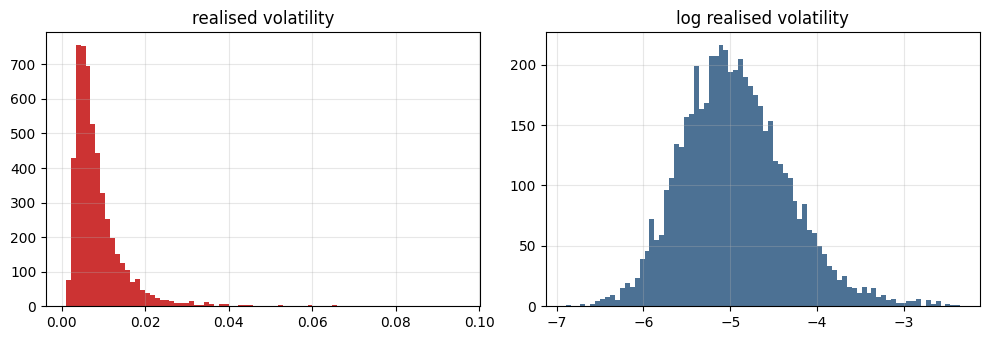

In [6]:
# Raw volatility is very skewed. Its logarithm is much closer to a normal bell shape,
# which is why the models tend to help most on the wild days in the right tail.
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].hist(feat["rv"] * scale_k, bins=80, color="#c00000", alpha=0.8)
ax[0].set_title("realised volatility"); ax[0].grid(alpha=0.3)
ax[1].hist(np.log(feat["rv"] * scale_k), bins=80, color="#1f4e79", alpha=0.8)
ax[1].set_title("log realised volatility"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

The three HAR features are just this volatility averaged over a day, a week and a
month. They move together (a calm week sits inside a calm month), which the next
notebook's models are happy to work with.

In [7]:
feat[["rv_d", "rv_w", "rv_m"]].corr().round(3)

,rv_d,rv_w,rv_m
rv_d,1.000,0.846,0.719
rv_w,0.846,1.000,0.867
rv_m,0.719,0.867,1.000
